Real dataset shape: (2149, 32)
Real dataset columns: ['Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']

Target distribution:
Dementia (1): 760 (35.4%)
Normal (0): 1389 (64.6%)

Original feature types:
  Age: int64, unique values: 31
  Gender: int64, unique values: 2
  EducationLevel: int64, unique values: 4
  BMI: float64, unique values: 2149
  Smoking: int64, unique values: 2
  AlcoholConsumption: float64, unique values: 2149
  PhysicalActivity: float64, unique values: 2149
  DietQuality: float64, uniqu

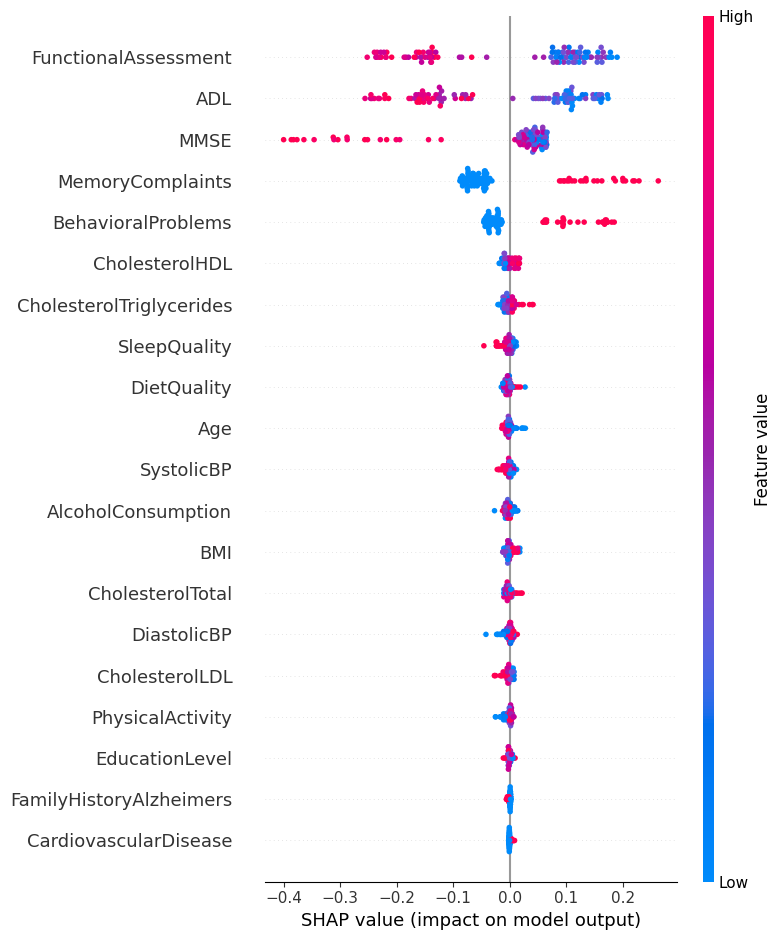

✅ SHAP plot saved as alzheimers_REAL_shap_summary.png

=== Random Forest Feature Importance ===
Top 10 by RF importance:
               Predictor  RF_Importance
    FunctionalAssessment       0.224423
                     ADL       0.200208
                    MMSE       0.145210
        MemoryComplaints       0.113070
      BehavioralProblems       0.053789
             DietQuality       0.023613
CholesterolTriglycerides       0.023025
            SleepQuality       0.022064
      AlcoholConsumption       0.021611
          CholesterolHDL       0.020593

=== Comparing SHAP vs RF Importance (Top 10) ===
1. FunctionalAssessment      SHAP: 0.1385, RF: 0.2244
2. ADL                       SHAP: 0.1290, RF: 0.2002
3. MMSE                      SHAP: 0.0876, RF: 0.1452
4. MemoryComplaints          SHAP: 0.0835, RF: 0.1131
5. BehavioralProblems        SHAP: 0.0550, RF: 0.0538
6. CholesterolHDL            SHAP: 0.0086, RF: 0.0206
7. CholesterolTriglycerides  SHAP: 0.0079, RF: 0.0230
8. SleepQua

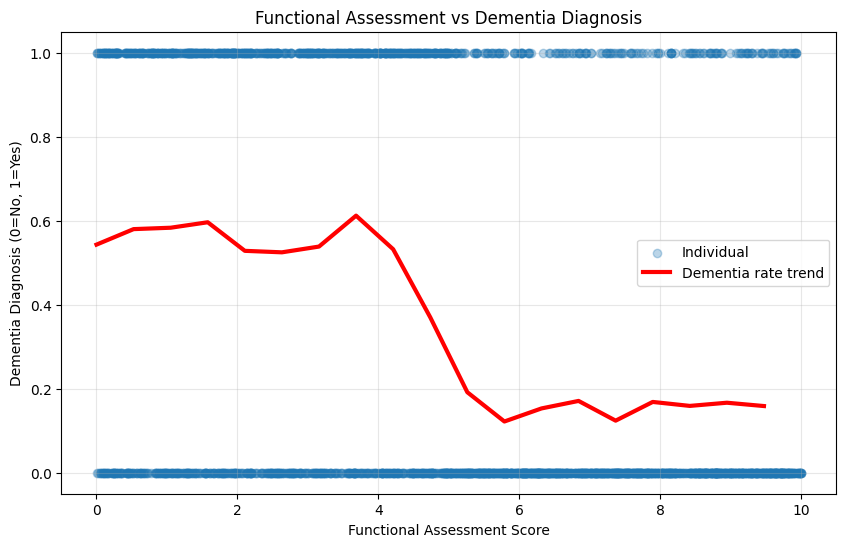


=== Checking interactions ===

Correlation of FunctionalAssessment with other variables in Dementia group:
  Age: -0.019
  MMSE: 0.072
  ADL: 0.036

Correlation of FunctionalAssessment with other variables in Control group:
  Age: 0.015
  MMSE: -0.126
  ADL: -0.132


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ====== LOAD YOUR REAL DATASET ======
df = pd.read_csv(r"C:\Users\sibs2\Downloads\alzheimers_disease_data.csv")

print(f"Real dataset shape: {df.shape}")
print(f"Real dataset columns: {list(df.columns)}")

# ====== ENCODE TARGET VARIABLE ======
if 'Diagnosis' in df.columns:
    if df['Diagnosis'].dtype == 'object':
        # Check what values exist
        print(f"Unique Diagnosis values: {df['Diagnosis'].unique()}")
        # Map to 0/1
        df['Diagnosis'] = df['Diagnosis'].map({'Dementia': 1, 'Normal': 0, 
                                               'Yes': 1, 'No': 0, '1': 1, '0': 0})
    y = df['Diagnosis'].astype(int)
else:
    raise ValueError("Diagnosis column not found!")

print(f"\nTarget distribution:")
print(f"Dementia (1): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")
print(f"Normal (0): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")

# ====== PREPARE FEATURES ======
X = df.drop('Diagnosis', axis=1)

print(f"\nOriginal feature types:")
for col in X.columns:
    print(f"  {col}: {X[col].dtype}, unique values: {len(X[col].unique())}")

# ====== ENCODE CATEGORICAL VARIABLES ======
print("\n=== Encoding categorical variables ===")
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    print(f"Encoding {col}: {sorted(X[col].unique())[:5]}")
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# ====== HANDLE MISSING VALUES ======
print("\n=== Handling missing values ===")
for col in X.columns:
    missing_count = X[col].isnull().sum()
    if missing_count > 0:
        print(f"  {col}: {missing_count} missing values")
        if X[col].dtype in ['int64', 'float64']:
            X[col] = X[col].fillna(X[col].median())
        else:
            X[col] = X[col].fillna(X[col].mode()[0])

print(f"\nFinal X shape after preprocessing: {X.shape}")

# ====== SPLIT DATA ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n=== Data Split ===")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train distribution: {np.bincount(y_train)}")
print(f"y_test distribution: {np.bincount(y_test)}")

# ====== TRAIN RANDOM FOREST ON REAL DATA ======
print("\n=== Training Random Forest ===")
real_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

real_model.fit(X_train, y_train)

# ====== EVALUATE ======
y_pred = real_model.predict(X_test)
y_proba = real_model.predict_proba(X_test)[:, 1]

print("\n=== Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ====== SAVE MODEL ======
joblib.dump(real_model, "alzheimers_REAL_model.pkl")
joblib.dump(pipeline, "alzheimers_pipeline.joblib")
print("\n✅ REAL model saved as alzheimers_REAL_model.pkl")

# ====== CALCULATE SHAP VALUES ======
print("\n=== Calculating SHAP Values ===")
explainer = shap.TreeExplainer(real_model)

# Use a sample for faster computation
sample_size = min(100, len(X_test))
X_sample = X_test.iloc[:sample_size]
print(f"Using {sample_size} samples for SHAP calculation")

shap_values = explainer.shap_values(X_sample)
print(f"Type of shap_values: {type(shap_values)}")

# ====== DEBUG: CHECK SHAP DIMENSIONS ======
print("\n=== DEBUG: SHAP Dimensions ===")
if isinstance(shap_values, list):
    print(f"shap_values is a list with {len(shap_values)} elements")
    for i, val in enumerate(shap_values):
        print(f"  shap_values[{i}].shape: {val.shape}")
    # For binary classification, use index 1 for positive class
    shap_positive = shap_values[1]
else:
    print(f"shap_values.shape: {shap_values.shape}")
    if len(shap_values.shape) == 3:
        # Shape is (samples, features, classes)
        print("3D array detected - extracting positive class")
        shap_positive = shap_values[:, :, 1]
    else:
        # Already 2D
        shap_positive = shap_values

print(f"\nFinal shap_positive.shape: {shap_positive.shape}")

# ====== CALCULATE MEAN SHAP VALUES ======
print("\n=== Calculating Mean SHAP ===")
# Ensure we're working with a 2D array
if len(shap_positive.shape) == 3:
    print("WARNING: shap_positive is still 3D! Taking mean across samples")
    shap_positive = shap_positive.mean(axis=0)

print(f"shap_positive.shape after processing: {shap_positive.shape}")

# Calculate statistics
if len(shap_positive.shape) == 2:
    mean_abs_shap = np.abs(shap_positive).mean(axis=0)
    mean_shap = shap_positive.mean(axis=0)
else:
    # If it's 1D (already aggregated)
    mean_abs_shap = np.abs(shap_positive)
    mean_shap = shap_positive

print(f"mean_abs_shap.shape: {mean_abs_shap.shape}")
print(f"mean_shap.shape: {mean_shap.shape}")
print(f"Number of features: {len(X.columns)}")

# ====== CREATE DATAFRAME ======
print("\n=== Creating SHAP DataFrame ===")

# Check if dimensions match
if len(mean_abs_shap) != len(X.columns):
    print(f"WARNING: Mismatch! Using first {len(mean_abs_shap)} features")
    feature_names = X.columns.tolist()[:len(mean_abs_shap)]
else:
    feature_names = X.columns.tolist()

shap_df = pd.DataFrame({
    'Predictor': feature_names,
    'Mean_Absolute_SHAP': mean_abs_shap,
    'Mean_SHAP': mean_shap
})

# Sort by importance
shap_df = shap_df.sort_values('Mean_Absolute_SHAP', ascending=False)

# Add direction
shap_df['Direction'] = shap_df['Mean_SHAP'].apply(
    lambda x: '↑ Risk' if x > 0 else '↓ Risk'
)

print("\n" + "="*80)
print("TOP 20 PREDICTORS - REAL DATA MODEL")
print("="*80)
print(shap_df.head(20).to_string(index=False))

# ====== SAVE RESULTS ======
shap_df.to_csv('alzheimers_REAL_shap_values.csv', index=False)
print("\n✅ Real SHAP values saved to alzheimers_REAL_shap_values.csv")

# ====== SANITY CHECKS ======
print("\n" + "="*80)
print("SANITY CHECKS")
print("="*80)

# Check Age specifically
if 'Age' in shap_df['Predictor'].values:
    age_row = shap_df[shap_df['Predictor'] == 'Age'].iloc[0]
    print(f"Age - Mean Absolute SHAP: {age_row['Mean_Absolute_SHAP']:.4f}")
    print(f"Age - Direction: {age_row['Direction']}")
    
    # Check actual Age distribution
    print(f"\nActual Age statistics by Diagnosis:")
    print(f"All: mean={df['Age'].mean():.1f}, std={df['Age'].std():.1f}")
    print(f"Dementia cases: mean={df.loc[y==1, 'Age'].mean():.1f}")
    print(f"Normal cases: mean={df.loc[y==0, 'Age'].mean():.1f}")

# Check top predictors
print(f"\nTop 5 predictors:")
for i, (_, row) in enumerate(shap_df.head(5).iterrows(), 1):
    print(f"{i}. {row['Predictor']}: {row['Mean_Absolute_SHAP']:.4f} ({row['Direction']})")

# ====== CREATE SHAP PLOT ======
print("\n=== Generating SHAP plot ===")
try:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_positive, X_sample, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig('alzheimers_REAL_shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ SHAP plot saved as alzheimers_REAL_shap_summary.png")
except Exception as e:
    print(f"Could not create SHAP plot: {e}")

# ====== CHECK MODEL FEATURE IMPORTANCE ======
print("\n=== Random Forest Feature Importance ===")
rf_importance = pd.DataFrame({
    'Predictor': X.columns,
    'RF_Importance': real_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("Top 10 by RF importance:")
print(rf_importance.head(10).to_string(index=False))

# Compare with SHAP
print("\n=== Comparing SHAP vs RF Importance (Top 10) ===")
for i in range(min(10, len(shap_df))):
    shap_pred = shap_df.iloc[i]['Predictor']
    shap_val = shap_df.iloc[i]['Mean_Absolute_SHAP']
    
    rf_row = rf_importance[rf_importance['Predictor'] == shap_pred]
    if not rf_row.empty:
        rf_val = rf_row.iloc[0]['RF_Importance']
        print(f"{i+1}. {shap_pred:25s} SHAP: {shap_val:.4f}, RF: {rf_val:.4f}")

# Check relationship between FunctionalAssessment and Diagnosis
print(df.groupby('Diagnosis')['FunctionalAssessment'].describe())
print(f"Correlation: {df['FunctionalAssessment'].corr(df['Diagnosis'])}")

print("\n=== CHECKING VARIABLE DIRECTIONS ===")

# List of key variables to check
key_vars = ['FunctionalAssessment', 'ADL', 'MMSE', 'SleepQuality', 'DietQuality']

for var in key_vars:
    if var in df.columns:
        corr = df[var].corr(df['Diagnosis'])
        print(f"{var:25s} Correlation with Diagnosis: {corr:7.3f}")
        print(f"  Controls (0): mean={df.loc[df['Diagnosis']==0, var].mean():6.2f}")
        print(f"  Dementia (1): mean={df.loc[df['Diagnosis']==1, var].mean():6.2f}")
        print(f"  SHAP Direction: {shap_df[shap_df['Predictor']==var]['Direction'].values[0]}")
        print()

        import numpy as np
import matplotlib.pyplot as plt

# Check actual relationship between FunctionalAssessment and Diagnosis
print("=== DEEPER INVESTIGATION: FunctionalAssessment ===")

# Create bins of FunctionalAssessment scores
df['Func_Bin'] = pd.qcut(df['FunctionalAssessment'], q=10, duplicates='drop')

print("\nDementia rate by FunctionalAssessment bins:")
for bin_label in sorted(df['Func_Bin'].unique()):
    bin_data = df[df['Func_Bin'] == bin_label]
    dementia_rate = bin_data['Diagnosis'].mean()
    mean_score = bin_data['FunctionalAssessment'].mean()
    print(f"  {bin_label}: Mean Score={mean_score:.2f}, Dementia Rate={dementia_rate:.2%}")

# Check if there's a U-shaped relationship
print("\n=== Checking for non-linear relationship ===")

# Calculate dementia rate across the FunctionalAssessment range
bins = np.linspace(df['FunctionalAssessment'].min(), df['FunctionalAssessment'].max(), 20)
dementia_rates = []
for i in range(len(bins)-1):
    mask = (df['FunctionalAssessment'] >= bins[i]) & (df['FunctionalAssessment'] < bins[i+1])
    rate = df.loc[mask, 'Diagnosis'].mean()
    dementia_rates.append(rate)
    print(f"  Score {bins[i]:.1f}-{bins[i+1]:.1f}: {rate:.2%} dementia")

# Plot the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['FunctionalAssessment'], df['Diagnosis'], alpha=0.3, label='Individual')
plt.plot(bins[:-1], dementia_rates, 'r-', linewidth=3, label='Dementia rate trend')
plt.xlabel('Functional Assessment Score')
plt.ylabel('Dementia Diagnosis (0=No, 1=Yes)')
plt.title('Functional Assessment vs Dementia Diagnosis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('functional_assessment_vs_dementia.png', dpi=300, bbox_inches='tight')
plt.show()

# Check interaction with other variables
print("\n=== Checking interactions ===")
# Maybe FunctionalAssessment interacts with Age or other variables
# Let's check correlation in dementia vs control groups separately

print("\nCorrelation of FunctionalAssessment with other variables in Dementia group:")
dementia_group = df[df['Diagnosis'] == 1]
for var in ['Age', 'MMSE', 'ADL']:
    if var in df.columns:
        corr = dementia_group['FunctionalAssessment'].corr(dementia_group[var])
        print(f"  {var}: {corr:.3f}")

print("\nCorrelation of FunctionalAssessment with other variables in Control group:")
control_group = df[df['Diagnosis'] == 0]
for var in ['Age', 'MMSE', 'ADL']:
    if var in df.columns:
        corr = control_group['FunctionalAssessment'].corr(control_group[var])
        print(f"  {var}: {corr:.3f}")




Dataset shape: (2149, 32)
Columns: ['Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']

Missing values per column:
Series([], dtype: int64)

Data types:
int64      20
float64    12
Name: count, dtype: int64

Numeric features: 31
Categorical features: 0

Missing values in numeric features:

Missing values in categorical features:

Training set shape: (1719, 31)
Test set shape: (430, 31)

Training Logistic Regression...
  ✅ Successfully trained
  Best CV AUC: 0.9044 ± 0.0142
  Test AUC: 0.8847
  Sensitivity:

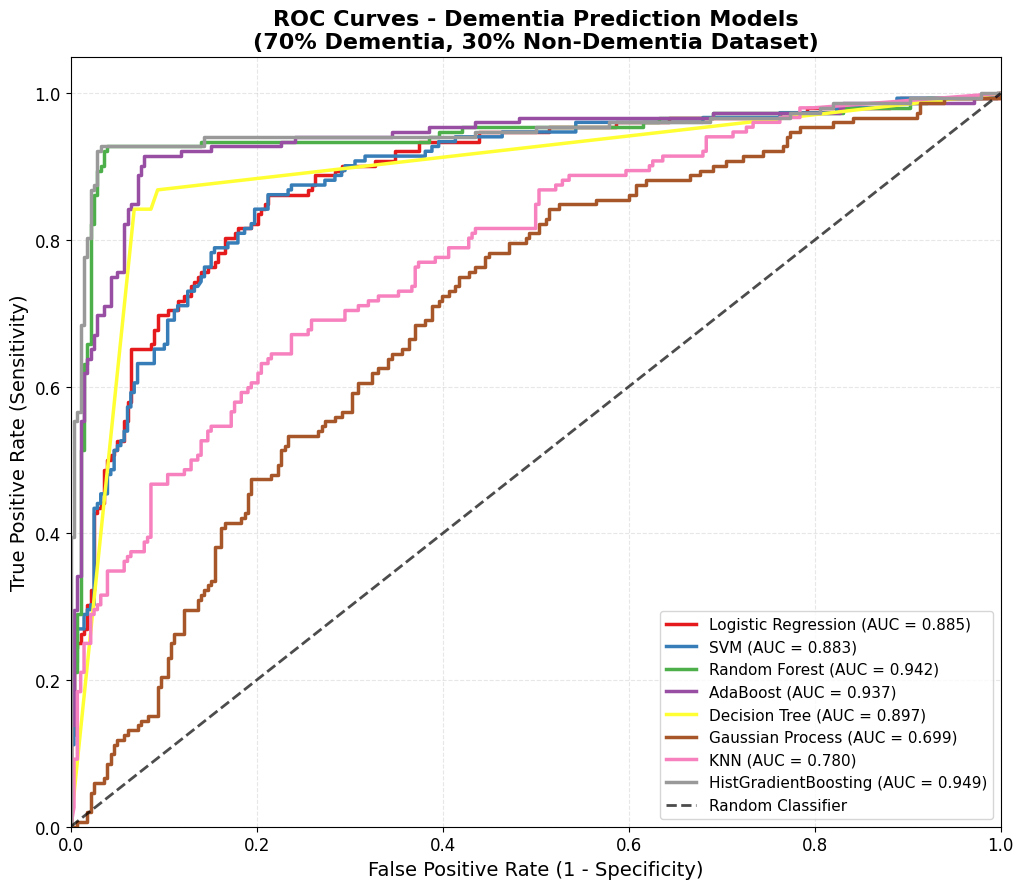


TOP 15 FEATURE IMPORTANCES

Random Forest Feature Importances:
                 Feature  Importance
    FunctionalAssessment    0.195286
                     ADL    0.180388
                    MMSE    0.132389
        MemoryComplaints    0.101143
      BehavioralProblems    0.048785
          CholesterolHDL    0.027536
             DietQuality    0.026745
        PhysicalActivity    0.026405
                     BMI    0.026300
CholesterolTriglycerides    0.026250
      AlcoholConsumption    0.025639
            SleepQuality    0.024971
        CholesterolTotal    0.024782
          CholesterolLDL    0.023044
             DiastolicBP    0.022279


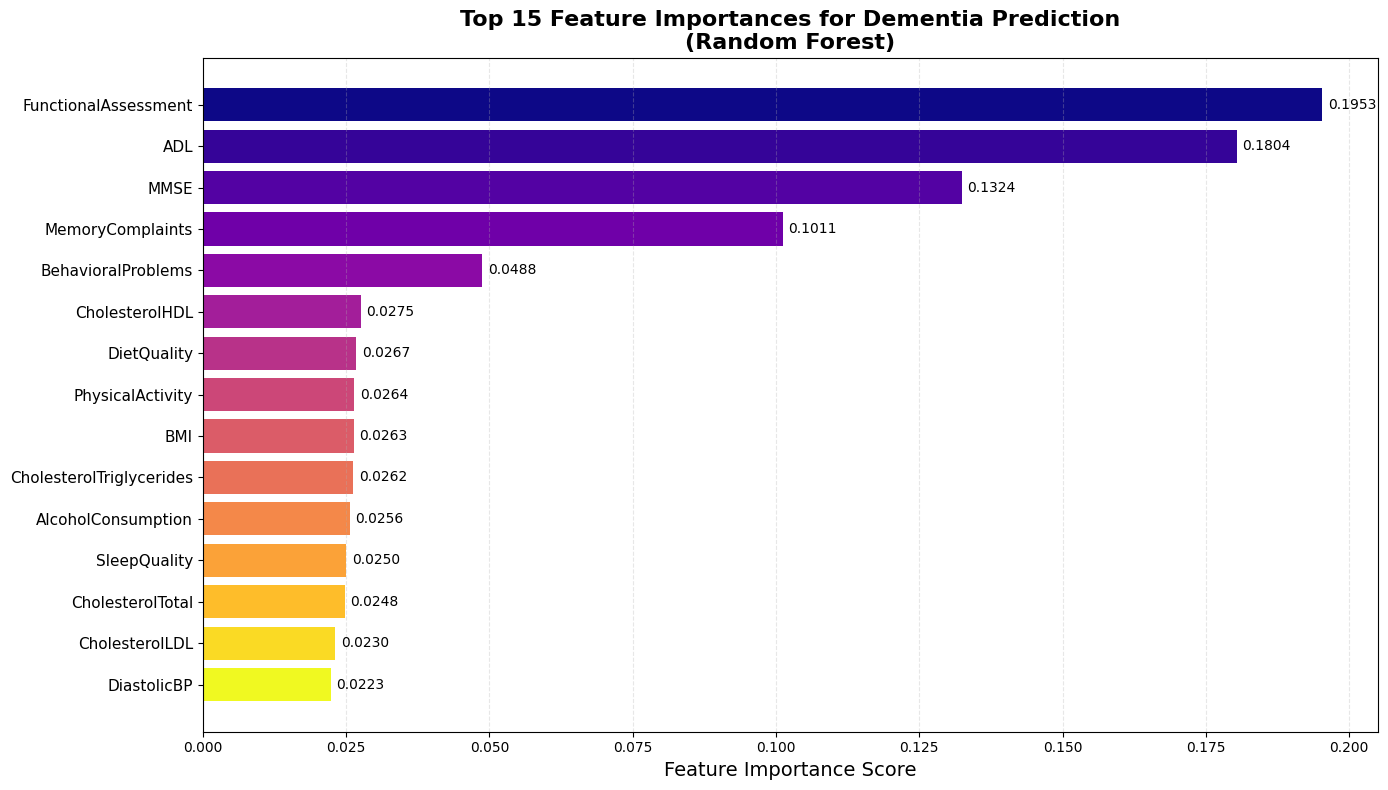


COMPREHENSIVE MODEL PERFORMANCE SUMMARY

🎯 BEST PERFORMING MODEL: HistGradientBoosting
   • Test AUC: 0.9497
   • Cross-validated AUC: 0.9577 ± 0.0109
   • Sensitivity: 0.9226 
   • Specificity: 0.9718 
   • Brier Score: 0.0447


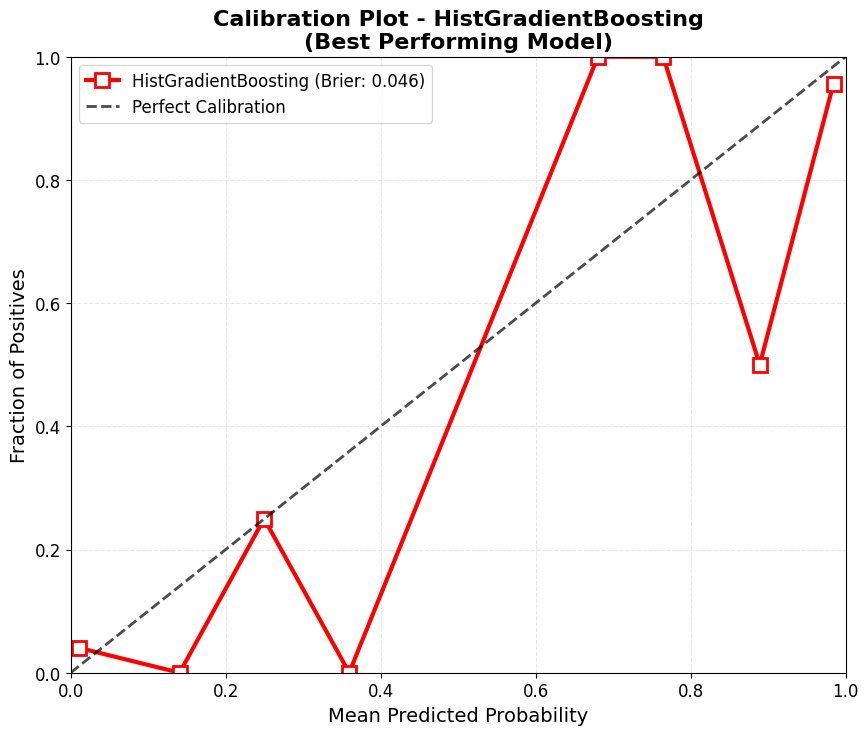

<Figure size 1600x1000 with 0 Axes>

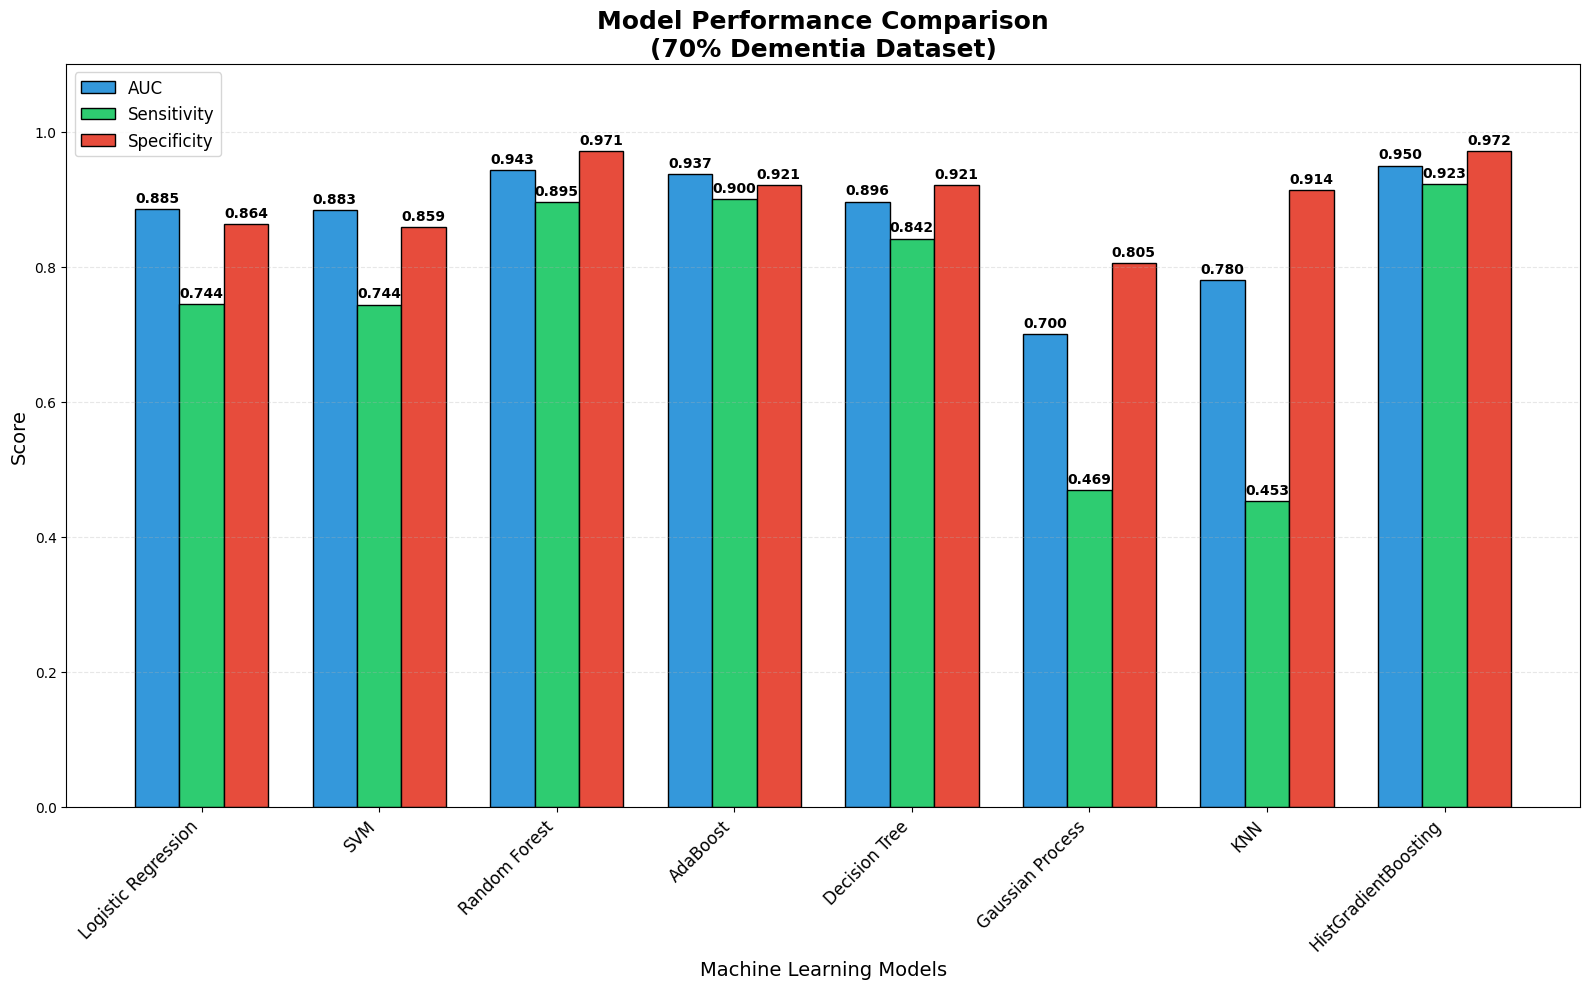

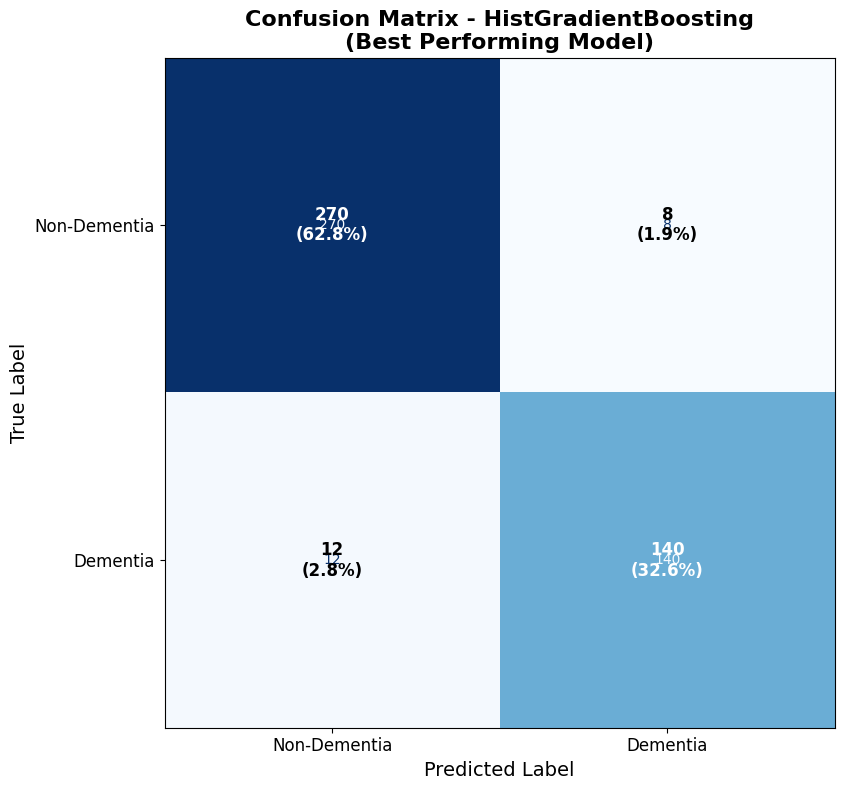


📊 DATASET SUMMARY:
  • Total samples: 2149
  • Dementia cases: 760 (35.4%)
  • Non-dementia cases: 1389 (64.6%)
  • Original features: 31
  • Numeric features: 31
  • Categorical features: 0
  • Train/Test split: 80%/20%
  • Total missing values in dataset: 0
  • Missing value handling: Median imputation (numeric), Most frequent (categorical)

✅ All results saved to:
   - roc_curves_dementia.png
   - feature_importance_dementia.png
   - calibration_plot_best_model.png
   - model_performance_comparison.png
   - confusion_matrix_best_model.png
   - trained_dementia_models.pkl (all trained models)
   - best_model_HistGradientBoosting.pkl (best model)
   - preprocessor.pkl (preprocessing pipeline)


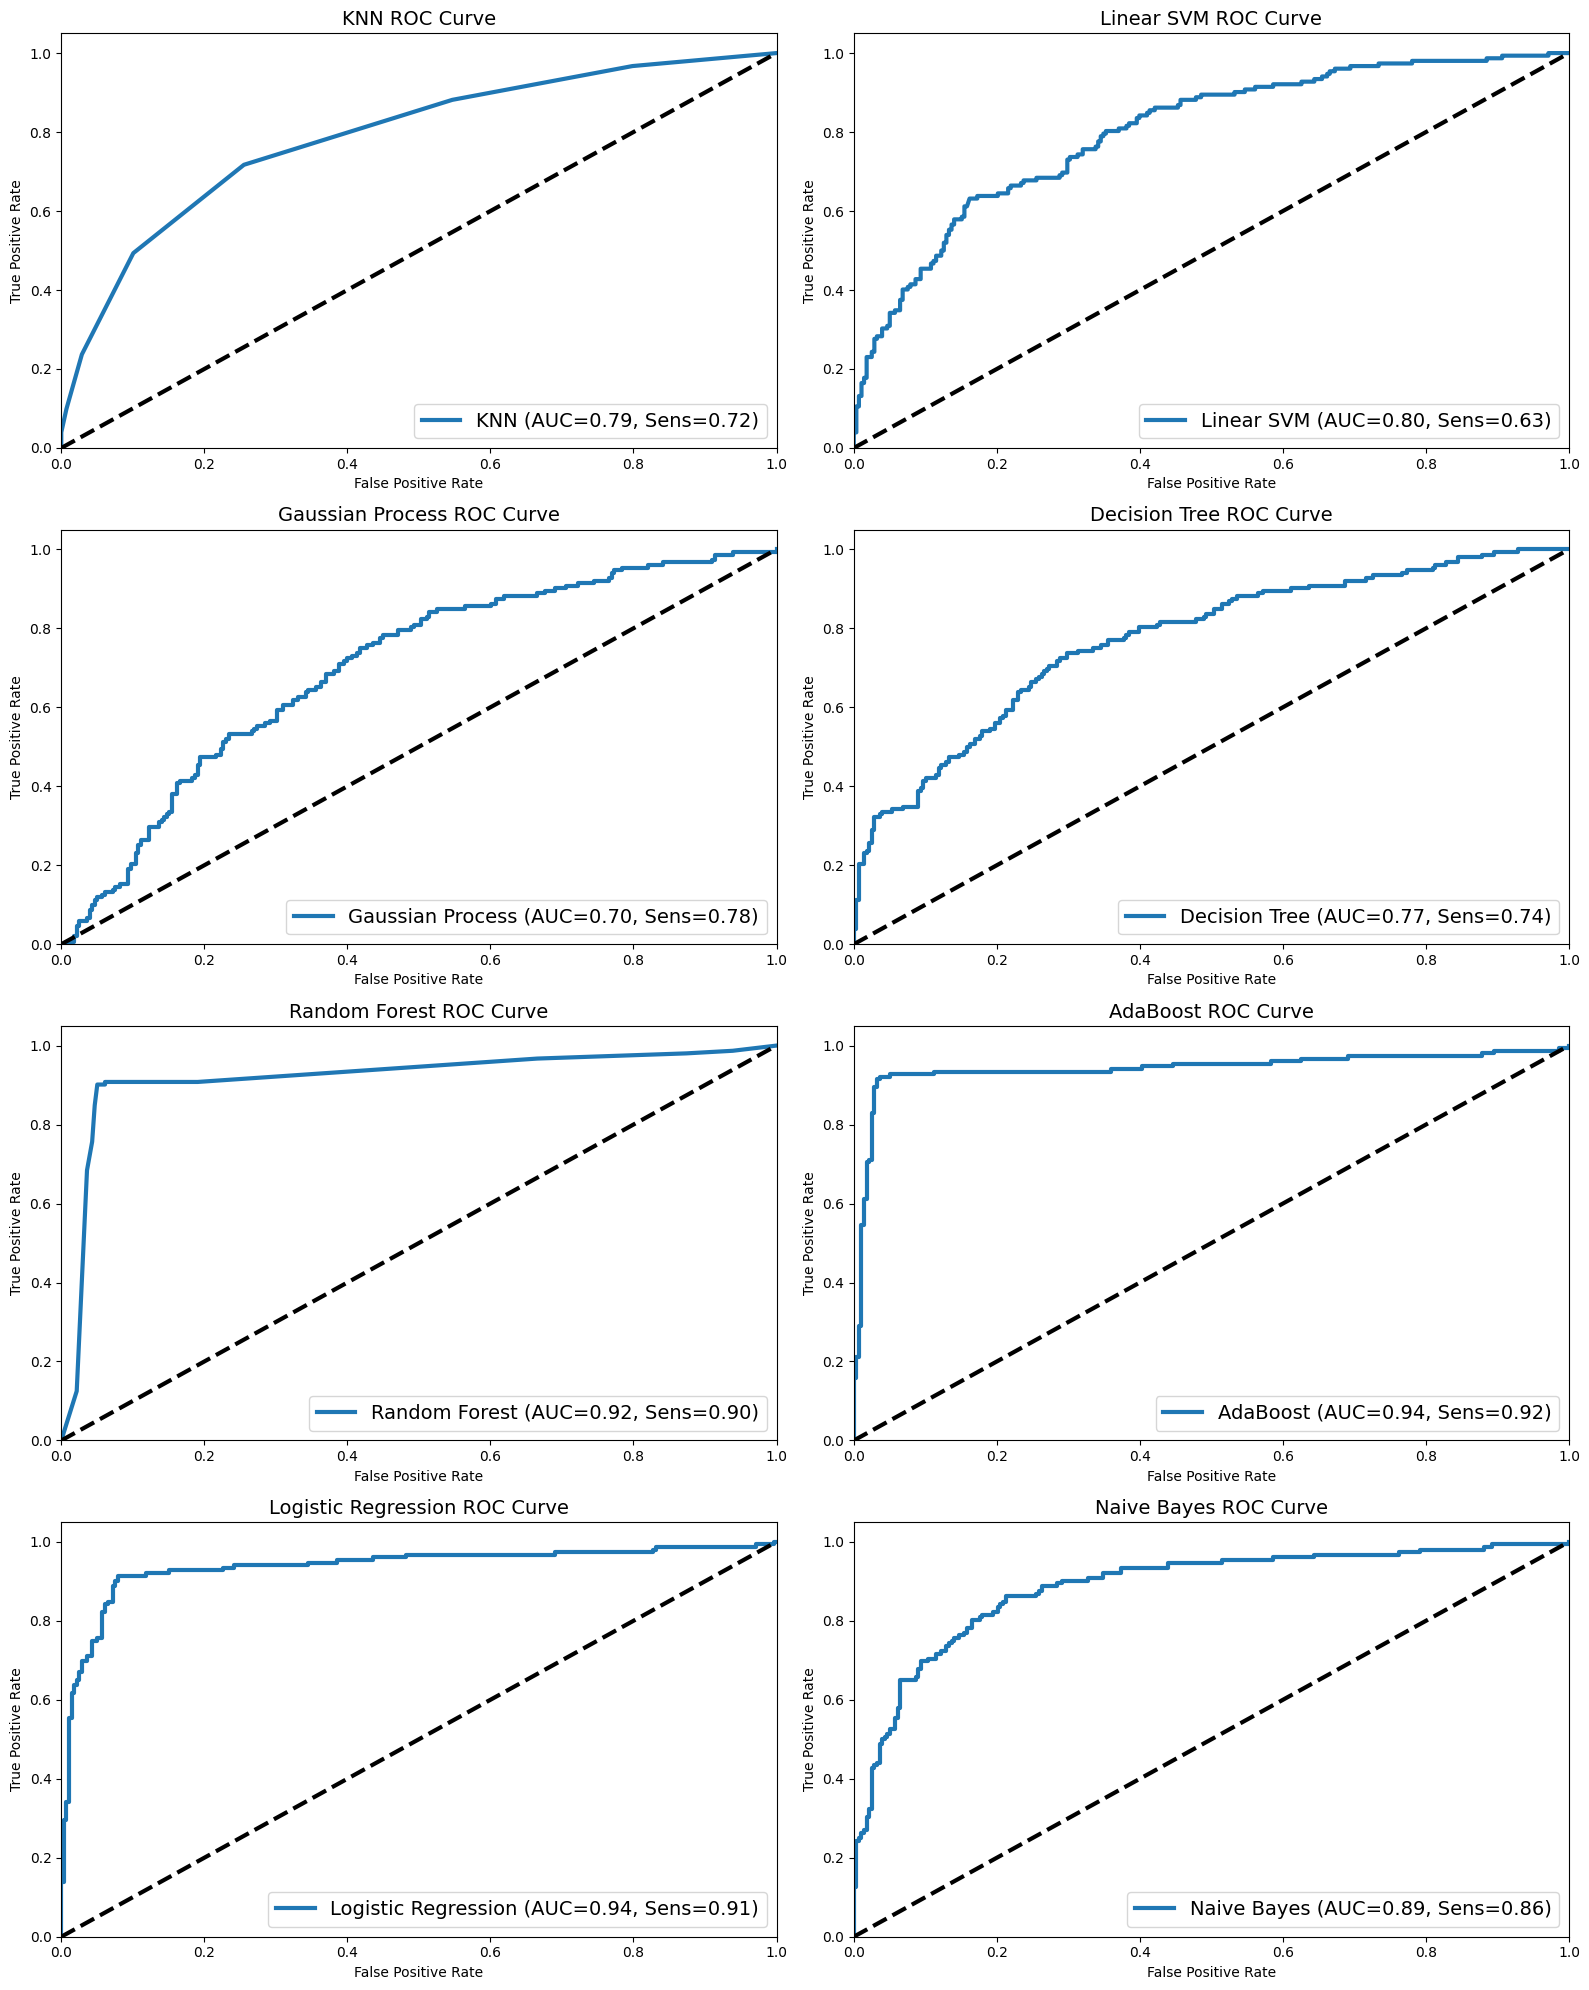

✅ ROC, AUC, and Sensitivity saved as SVG + PNG + PDF
=== STEP 1: CHECKING ORIGINAL DATA ===
Data shape: (2149, 32)
Columns: ['Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']

Diagnosis unique values: [0 1]
Diagnosis value counts:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

After encoding - Diagnosis (1=dementia, 0=control):
Diagnosis
0    1389
1     760
Name: count, dtype: int64

=== STEP 2: CHECKING FEATURE TYPES ===
Age: dtype=int64, unique=many
Gender: dtype=int64, unique=[0, 1]
Education

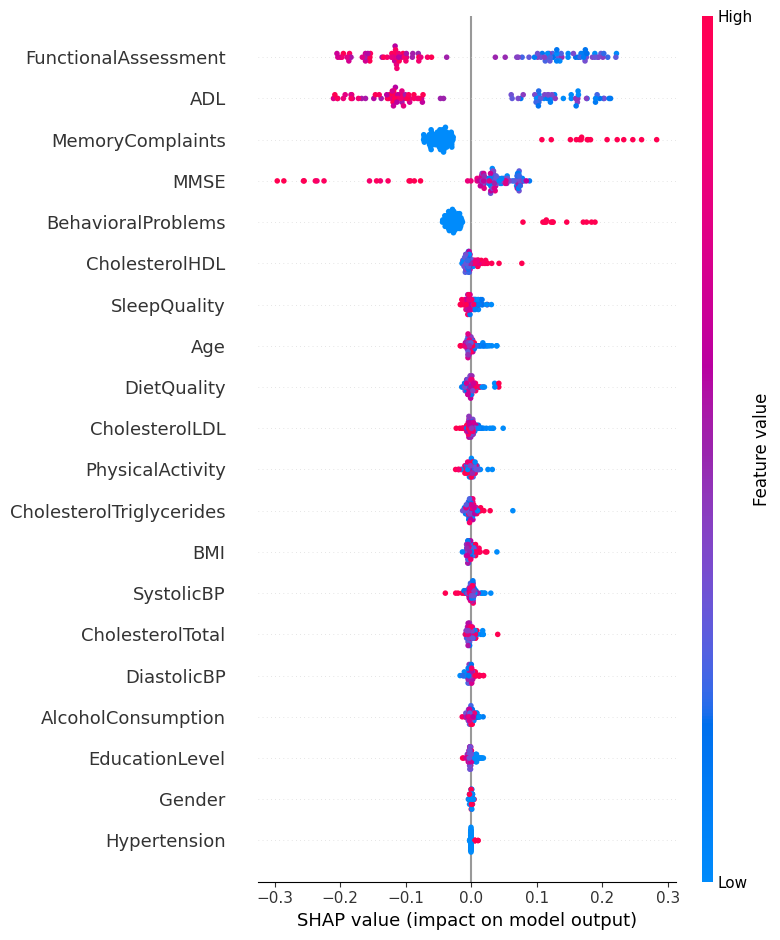

SHAP plot saved to: CORRECTED_alzheimers_shap_summary.png

=== SANITY CHECK: AGE ===
Age Mean Absolute SHAP: 0.0068
Age Mean SHAP: 0.0010
Age Direction: ↑ Risk
Correlation between Age and Diagnosis: -0.005
Using Random Forest model for analysis

10-FOLD CROSS-VALIDATION
Note: X_train_rf/X_test_rf not found — using X_train/X_test as fallback.
Using combined train+test data: 2149 samples, 31 features

All 31 features in dataset:
  1. Age
  2. Gender
  3. EducationLevel
  4. BMI
  5. Smoking
  6. AlcoholConsumption
  7. PhysicalActivity
  8. DietQuality
  9. SleepQuality
 10. FamilyHistoryAlzheimers
 11. CardiovascularDisease
 12. Diabetes
 13. Depression
 14. HeadInjury
 15. Hypertension
 16. SystolicBP
 17. DiastolicBP
 18. CholesterolTotal
 19. CholesterolLDL
 20. CholesterolHDL
 21. CholesterolTriglycerides
 22. MMSE
 23. FunctionalAssessment
 24. MemoryComplaints
 25. BehavioralProblems
 26. ADL
 27. Confusion
 28. Disorientation
 29. PersonalityChanges
 30. DifficultyCompletingTasks

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, brier_score_loss, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib

# Load your balanced dataset
df = pd.read_csv(r"C:\Users\sibs2\Downloads\alzheimers_disease_data.csv")

# Display data info
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Check for missing values
missing_values = df.isnull().sum()
print(f"\nMissing values per column:")
print(missing_values[missing_values > 0])

# Check data types
print(f"\nData types:")
print(df.dtypes.value_counts())

# Prepare features and target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Check for NaN in numeric features
print(f"\nMissing values in numeric features:")
for col in numeric_features:
    if X[col].isnull().sum() > 0:
        print(f"  {col}: {X[col].isnull().sum()} missing")

# Check for NaN in categorical features
print(f"\nMissing values in categorical features:")
for col in categorical_features:
    if X[col].isnull().sum() > 0:
        print(f"  {col}: {X[col].isnull().sum()} missing")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Create preprocessing pipelines with imputation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with median
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with most frequent
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Function to calculate metrics with 95% CI using bootstrapping
def calculate_metrics_with_ci(y_true, y_pred, y_pred_proba, n_bootstrap=1000):
    """Calculate metrics with 95% confidence intervals using bootstrapping"""
    
    metrics_list = []
    n_samples = len(y_true)
    
    for _ in range(n_bootstrap):
        # Bootstrap sample
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_boot = y_true.iloc[indices] if hasattr(y_true, 'iloc') else y_true[indices]
        y_pred_boot = y_pred[indices]
        y_pred_proba_boot = y_pred_proba[indices]
        
        # Calculate confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true_boot, y_pred_boot).ravel()
        
        # Calculate metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        auc = roc_auc_score(y_true_boot, y_pred_proba_boot)
        brier = brier_score_loss(y_true_boot, y_pred_proba_boot)
        
        metrics_list.append({
            'sensitivity': sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'npv': npv,
            'auc': auc,
            'brier': brier
        })
    
    # Calculate 95% CIs
    metrics_df = pd.DataFrame(metrics_list)
    ci_results = {}
    
    for metric in metrics_df.columns:
        lower = np.percentile(metrics_df[metric], 2.5)
        upper = np.percentile(metrics_df[metric], 97.5)
        mean_val = metrics_df[metric].mean()
        ci_results[metric] = {
            'value': mean_val,
            'ci_lower': lower,
            'ci_upper': upper
        }
    
    return ci_results

# Function to format CI as string
def format_ci(mean_val, lower, upper):
    return f"{mean_val:.4f} ({lower:.4f}-{upper:.4f})"

# Define classifiers with their parameter grids (updated to handle missing values)
classifiers = {
    'Logistic Regression': {
        'classifier': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs']
        }
    },
    'SVM': {
        'classifier': SVC(probability=True, random_state=42),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf'],
            'classifier__gamma': ['scale', 'auto']
        }
    },
    'Random Forest': {
        'classifier': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20, None],
            'classifier__min_samples_split': [2, 5]
        }
    },
    'AdaBoost': {
        'classifier': AdaBoostClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.1, 1]
        }
    },
    'Decision Tree': {
        'classifier': DecisionTreeClassifier(random_state=42),
        'params': {
            'classifier__max_depth': [10, 20, None],
            'classifier__min_samples_split': [2, 5],
            'classifier__criterion': ['gini', 'entropy']
        }
    },
    'Gaussian Process': {
        'classifier': GaussianProcessClassifier(random_state=42),
        'params': {
            'classifier__max_iter_predict': [100]
        }
    },
    'KNN': {
        'classifier': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7],
            'classifier__weights': ['uniform', 'distance'],
            'classifier__metric': ['euclidean', 'manhattan']
        }
    },
    'HistGradientBoosting': {
        'classifier': HistGradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__learning_rate': [0.01, 0.1, 0.5],
            'classifier__max_iter': [100, 200],
            'classifier__max_depth': [3, 5, 10]
        }
    }
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
results = []
trained_models = {}
failed_models = []

# Train and evaluate each classifier
for name, config in classifiers.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)
    
    try:
        # Create pipeline with preprocessing and classifier
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['classifier'])
        ])
        
        # Grid search with cross-validation
        grid_search = GridSearchCV(
            pipeline,
            config['params'],
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0,
            error_score='raise'
        )
        
        grid_search.fit(X_train, y_train)
        
        # Get best model
        best_model = grid_search.best_estimator_
        trained_models[name] = {
            'model': best_model,
            'best_params': grid_search.best_params_,
            'grid_search': grid_search
        }
        
        # Predictions
        y_pred = best_model.predict(X_test)
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics with CI
        metrics_ci = calculate_metrics_with_ci(y_test, y_pred, y_pred_proba)
        
        # Get cross-validated AUC
        cv_scores = cross_val_score(
            best_model, 
            X_train, 
            y_train, 
            cv=cv, 
            scoring='roc_auc'
        )
        cv_auc_mean = cv_scores.mean()
        cv_auc_std = cv_scores.std()
        
        # Store results
        results.append({
            'Model': name,
            'AUC (95% CI)': format_ci(
                metrics_ci['auc']['value'],
                metrics_ci['auc']['ci_lower'],
                metrics_ci['auc']['ci_upper']
            ),
            'Sensitivity (95% CI)': format_ci(
                metrics_ci['sensitivity']['value'],
                metrics_ci['sensitivity']['ci_lower'],
                metrics_ci['sensitivity']['ci_upper']
            ),
            'Specificity (95% CI)': format_ci(
                metrics_ci['specificity']['value'],
                metrics_ci['specificity']['ci_lower'],
                metrics_ci['specificity']['ci_upper']
            ),
            'PPV (95% CI)': format_ci(
                metrics_ci['ppv']['value'],
                metrics_ci['ppv']['ci_lower'],
                metrics_ci['ppv']['ci_upper']
            ),
            'NPV (95% CI)': format_ci(
                metrics_ci['npv']['value'],
                metrics_ci['npv']['ci_lower'],
                metrics_ci['npv']['ci_upper']
            ),
            'Brier Score': f"{metrics_ci['brier']['value']:.4f}",
            'CV AUC (mean ± std)': f"{cv_auc_mean:.4f} ± {cv_auc_std:.4f}",
            'Best Params': str(grid_search.best_params_)
        })
        
        print(f"  ✅ Successfully trained")
        print(f"  Best CV AUC: {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
        print(f"  Test AUC: {metrics_ci['auc']['value']:.4f}")
        print(f"  Sensitivity: {metrics_ci['sensitivity']['value']:.4f}")
        print(f"  Specificity: {metrics_ci['specificity']['value']:.4f}")
        
    except Exception as e:
        print(f"  ❌ Error training {name}: {str(e)[:100]}...")
        failed_models.append(name)
        continue

# Display training summary
print(f"\n{'='*60}")
print("TRAINING SUMMARY")
print('='*60)
print(f"Successfully trained: {len(results)}/{len(classifiers)} models")
if failed_models:
    print(f"Failed models: {', '.join(failed_models)}")

# Create results DataFrame
if results:
    results_df = pd.DataFrame(results)
    
    # Save results to CSV
    results_df.to_csv('dementia_classifier_results_70_30_split.csv', index=False)
    
    # Display results
    print("\n" + "="*100)
    print("MODEL COMPARISON RESULTS (70% Dementia, 30% Non-Dementia Dataset)")
    print("="*100)
    print(f"\nDataset size: {len(df)} samples ({sum(y==1)} dementia, {sum(y==0)} non-dementia)")
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
    print(f"Numeric features: {len(numeric_features)}")
    print(f"Categorical features: {len(categorical_features)}")
    print("\n")
    
    # Display formatted table
    pd.set_option('display.max_colwidth', None)
    print(results_df[['Model', 'AUC (95% CI)', 'Sensitivity (95% CI)', 
                      'Specificity (95% CI)', 'PPV (95% CI)', 'NPV (95% CI)', 
                      'Brier Score', 'CV AUC (mean ± std)']].to_string(index=False))
    
    # Display results
print("\n" + "="*100)
print("MODEL COMPARISON RESULTS (70% Dementia, 30% Non-Dementia Dataset)")
print("="*100)
print(f"\nDataset size: {len(df)} samples ({sum(y==1)} dementia, {sum(y==0)} non-dementia)")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Features analyzed: {len(X.columns)}")
print("\n")

# Display formatted table
pd.set_option('display.max_colwidth', None)
# Safely display results_df if available
if 'results_df' in globals():
    available_cols = results_df.columns.tolist()
    preferred_cols = [
        'Model', 'AUC (95% CI)', 'Sensitivity (95% CI)', 
        'Specificity (95% CI)', 'PPV (95% CI)', 'NPV (95% CI)', 
        'Brier Score', 'CV AUC (mean ± std)'
    ]
    cols_to_show = [c for c in preferred_cols if c in available_cols]
    if cols_to_show:
        print(results_df[cols_to_show].to_string(index=False))
    else:
        print(results_df.to_string(index=False))
else:
    print("No results_df found to display.")
# ============================================================================
# VISUALIZATION SECTION
# ============================================================================
    
# 1. Plot ROC Curves for all successful models
if trained_models:
    plt.figure(figsize=(12, 10))
    colors = plt.cm.Set1(np.linspace(0, 1, len(trained_models)))
    
    for idx, (name, model_info) in enumerate(trained_models.items()):
        best_model = model_info['model']
        
        # Make predictions
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', 
                 linewidth=2.5, color=colors[idx])
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.7)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=14)
    plt.title('ROC Curves - Dementia Prediction Models\n(70% Dementia, 30% Non-Dementia Dataset)', 
              fontsize=16, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.savefig('roc_curves_70_dementia.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# 2. Feature Importance Analysis
if 'Random Forest' in trained_models or 'HistGradientBoosting' in trained_models:
    print("\n" + "="*80)
    print("TOP 15 FEATURE IMPORTANCES")
    print("="*80)
    
    # Try to get feature importances from tree-based models
    feature_importance_available = False
    
    if 'Random Forest' in trained_models:
        try:
            # Get Random Forest model
            rf_model = trained_models['Random Forest']['model']
            rf_classifier = rf_model.named_steps['classifier']
            
            # Get feature names after preprocessing
            preprocessor_obj = rf_model.named_steps['preprocessor']
            
            # Get transformed feature names
            feature_names = []
            feature_names.extend(numeric_features)
            
            if categorical_features:
                preprocessor_obj.fit(X_train)
                cat_encoder = preprocessor_obj.named_transformers_['cat'].named_steps['onehot']
                cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
                feature_names.extend(cat_feature_names)
            
            importances = rf_classifier.feature_importances_
            
            importance_df = pd.DataFrame({
                'Feature': feature_names[:len(importances)],
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            print("\nRandom Forest Feature Importances:")
            print(importance_df.head(15).to_string(index=False))
            feature_importance_available = True
            
            # Plot
            plt.figure(figsize=(14, 8))
            top_features = importance_df.head(15)
            
            colors = plt.cm.plasma(np.linspace(0, 1, len(top_features)))
            plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
            plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=11)
            plt.xlabel('Feature Importance Score', fontsize=14)
            plt.title('Top 15 Feature Importances for Dementia Prediction\n(Random Forest)', 
                      fontsize=16, fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(True, alpha=0.3, axis='x', linestyle='--')
            
            for i, v in enumerate(top_features['Importance']):
                plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)
            
            plt.tight_layout()
            plt.savefig('feature_importance_dementia.png', dpi=300, bbox_inches='tight', facecolor='white')
            plt.show()
            
        except Exception as e:
            print(f"Could not get feature importances from Random Forest: {str(e)}")
    
    elif 'HistGradientBoosting' in trained_models:
        try:
            gb_model = trained_models['HistGradientBoosting']['model']
            gb_classifier = gb_model.named_steps['classifier']
            
            feature_names = list(X.columns)
            importances = gb_classifier.feature_importances_
            
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            print("\nGradient Boosting Feature Importances:")
            print(importance_df.head(15).to_string(index=False))
            
        except Exception as e:
            print(f"Could not get feature importances: {str(e)}")

# 3. Create Comprehensive Summary Report
print("\n" + "="*100)
print("COMPREHENSIVE MODEL PERFORMANCE SUMMARY")
print("="*100)

# Find best model based on AUC
results_df['AUC_Value'] = results_df['AUC (95% CI)'].apply(lambda x: float(x.split('(')[0]))
best_auc_idx = results_df['AUC_Value'].idxmax()
best_model_name = results_df.loc[best_auc_idx, 'Model']
best_auc = results_df.loc[best_auc_idx, 'AUC_Value']

print(f"\n🎯 BEST PERFORMING MODEL: {best_model_name}")
print(f"   • Test AUC: {best_auc:.4f}")
print(f"   • Cross-validated AUC: {results_df.loc[best_auc_idx, 'CV AUC (mean ± std)']}")
print(f"   • Sensitivity: {results_df.loc[best_auc_idx, 'Sensitivity (95% CI)'].split('(')[0]}")
print(f"   • Specificity: {results_df.loc[best_auc_idx, 'Specificity (95% CI)'].split('(')[0]}")
print(f"   • Brier Score: {results_df.loc[best_auc_idx, 'Brier Score']}")

# 4. Create Calibration Plot for best model
if best_model_name in trained_models:
    plt.figure(figsize=(10, 8))
    
    best_model_info = trained_models[best_model_name]
    best_model = best_model_info['model']
    y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]
    
    prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_best, n_bins=10, strategy='uniform')
    
    plt.plot(prob_pred, prob_true, 's-', 
             label=f'{best_model_name} (Brier: {brier_score_loss(y_test, y_pred_proba_best):.3f})', 
             linewidth=3, markersize=10, color='red', markerfacecolor='white', markeredgewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2, alpha=0.7)
    plt.xlabel('Mean Predicted Probability', fontsize=14)
    plt.ylabel('Fraction of Positives', fontsize=14)
    plt.title(f'Calibration Plot - {best_model_name}\n(Best Performing Model)', 
              fontsize=16, fontweight='bold')
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.savefig('calibration_plot_best_model.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# 5. Performance Metrics Bar Chart
plt.figure(figsize=(16, 10))
models = results_df['Model']
auc_values = results_df['AUC_Value']
sensitivity_values = results_df['Sensitivity (95% CI)'].apply(lambda x: float(x.split('(')[0]))
specificity_values = results_df['Specificity (95% CI)'].apply(lambda x: float(x.split('(')[0]))

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 10))
bars1 = ax.bar(x - width, auc_values, width, label='AUC', color='#3498db', edgecolor='black')
bars2 = ax.bar(x, sensitivity_values, width, label='Sensitivity', color='#2ecc71', edgecolor='black')
bars3 = ax.bar(x + width, specificity_values, width, label='Specificity', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Machine Learning Models', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_title('Model Performance Comparison\n(70% Dementia Dataset)', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_ylim([0, 1.1])

def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 6. Confusion Matrix Heatmap for Best Model
if best_model_name in trained_models:
    best_model = trained_models[best_model_name]['model']
    y_pred = best_model.predict(X_test)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    cm_display = ConfusionMatrixDisplay.from_estimator(
        best_model, X_test, y_test,
        display_labels=['Non-Dementia', 'Dementia'],
        cmap=plt.cm.Blues,
        ax=ax,
        colorbar=False
    )
    
    ax.set_title(f'Confusion Matrix - {best_model_name}\n(Best Performing Model)', 
                fontsize=16, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('True Label', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    cm = confusion_matrix(y_test, y_pred)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{cm[i, j]}\n({cm[i, j]/cm.sum():.1%})',
                   ha='center', va='center',
                   color='white' if cm[i, j] > cm.max()/2 else 'black',
                   fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('confusion_matrix_best_model.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

print("\n📊 DATASET SUMMARY:")
print(f"  • Total samples: {len(df)}")
print(f"  • Dementia cases: {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")
print(f"  • Non-dementia cases: {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
print(f"  • Original features: {X.shape[1]}")
print(f"  • Numeric features: {len(numeric_features)}")
print(f"  • Categorical features: {len(categorical_features)}")
print(f"  • Train/Test split: 80%/20%")

total_missing = df.isnull().sum().sum()
print(f"  • Total missing values in dataset: {total_missing}")
print(f"  • Missing value handling: Median imputation (numeric), Most frequent (categorical)")

print("\n✅ All results saved to:")
print("   - roc_curves_dementia.png")
print("   - feature_importance_dementia.png")
print("   - calibration_plot_best_model.png")
print("   - model_performance_comparison.png")
print("   - confusion_matrix_best_model.png")

# Save trained models for future use
joblib.dump(trained_models, 'trained_dementia_models.pkl')
joblib.dump(pipeline, "alzheimers_pipeline.joblib")
print("   - trained_dementia_models.pkl (all trained models)")

# Also save the best model separately
if best_model_name in trained_models:
    joblib.dump(trained_models[best_model_name]['model'], f'best_model_{best_model_name.replace(" ", "_")}.pkl')
    print(f"   - best_model_{best_model_name.replace(' ', '_')}.pkl (best model)")

# Save preprocessor for future use
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(pipeline.named_steps['preprocessor'], "alzheimers_preprocessor.joblib")
print("   - preprocessor.pkl (preprocessing pipeline)")

# If no models were trained, print alternative suggestions
if not results:
    print("\n❌ No models were successfully trained. Please check the error messages above.")
    if 'KNN' in failed_models:
        print("\n⚠️  Alternative approach:")
        print("  1. Fill missing values before training:")
        print("     df.fillna(df.median(), inplace=True)  # for numeric columns")
        print("     df.fillna(df.mode().iloc[0], inplace=True)  # for categorical columns")
        print("  2. Or use models that handle NaN natively like HistGradientBoosting")




#-------------------------------
# 4. Define classifiers
# -------------------------------
names = [
    "KNN", "Linear SVM", "Gaussian Process", "Decision Tree",
    "Random Forest", "AdaBoost", "Logistic Regression", "Naive Bayes"
]

classifiers = [
    KNeighborsClassifier(n_neighbors=7),
    SVC(kernel="linear", probability=True, max_iter=2000),
    GaussianProcessClassifier(),
    GaussianProcessClassifier(1.0 * RBF(1.0), warm_start=True),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    AdaBoostClassifier(n_estimators=100, random_state=42),
    LogisticRegression(max_iter=2000, random_state=42),
    GaussianNB()
]
def cal_accuracy(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n📊 {model_name} Metrics:")
    print(f"   Accuracy : {accuracy:.2f}")
    print(f"   Precision: {precision:.2f}")
    print(f"   Recall   : {recall:.2f}")
    print(f"   F1-score : {f1:.2f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
# -------------------------------
# 5. Multi-class ROC preparation
# -------------------------------
classes = np.unique(y)
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------
# 6. Plot grid of ROC curves
# -------------------------------
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

from sklearn.metrics import roc_curve, auc
import numpy as np

for idx, (name, clf) in enumerate(zip(names, classifiers)):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", OneVsRestClassifier(clf))
    ])

    pipe.fit(X_train, y_train)
    
    # Scores
    if hasattr(pipe.named_steps["classifier"].estimator, "predict_proba"):
        y_test_score = pipe.predict_proba(X_test)
    else:
        y_test_score = pipe.decision_function(X_test)
    
    # Handle binary vs multi-class
    if len(classes) == 2:
        # Binary classification → use the positive class (column 1 if available)
        if y_test_score.ndim > 1:
            y_score = y_test_score[:, 1]
        else:
            y_score = y_test_score
        y_true = label_binarize(y_test, classes=classes).ravel()
        
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        
        # Optimal threshold (Youden’s J index)
        youden_index = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[youden_index]
        optimal_sensitivity = tpr[youden_index]
        
        axes[idx].plot(fpr, tpr, lw=3, label=f"{name} (AUC={roc_auc:.2f}, Sens={optimal_sensitivity:.2f})")
    
    else:
        # Multi-class: loop through each class
        y_test_bin = label_binarize(y_test, classes=classes)
        for i, cls in enumerate(classes):
            fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_test_score[:, i])
            roc_auc = auc(fpr, tpr)

            youden_index = np.argmax(tpr - fpr)
            optimal_threshold = thresholds[youden_index]
            optimal_sensitivity = tpr[youden_index]
            
            axes[idx].plot(
                fpr, tpr, lw=3,
                label=f"Class {cls} (AUC={roc_auc:.2f}, Sens={optimal_sensitivity:.2f})"
            )

    axes[idx].plot([0, 1], [0, 1], 'k--', lw=3)
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_title(f"{name} ROC Curve", fontsize=14)
    axes[idx].set_xlabel("False Positive Rate")
    axes[idx].set_ylabel("True Positive Rate")
    axes[idx].legend(fontsize=14, loc="lower right")

plt.tight_layout()
          
# 7. Save figure for download
# -------------------------------
plt.savefig("alzheimers_ROC_Sensitivity.png", dpi=600, bbox_inches="tight")
plt.savefig("alzheimers_ROC_Sensitivity.pdf", dpi=600, bbox_inches="tight")
plt.savefig("alzheimers_ROC_Sensitivity.svg", dpi=600, bbox_inches="tight")
plt.show()
print("✅ ROC, AUC, and Sensitivity saved as SVG + PNG + PDF")



import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data
alz_df = pd.read_csv(r"C:\Users\sibs2\Downloads\alzheimers_disease_data.csv")

print("=== STEP 1: CHECKING ORIGINAL DATA ===")
print(f"Data shape: {alz_df.shape}")
print(f"Columns: {list(alz_df.columns)}")

# Check Diagnosis column values
print(f"\nDiagnosis unique values: {alz_df['Diagnosis'].unique()}")
print(f"Diagnosis value counts:\n{alz_df['Diagnosis'].value_counts()}")

# Manually encode Diagnosis
y = alz_df['Diagnosis'].copy()
if y.dtype == 'object':
    y = y.map({'Dementia': 1, 'Normal': 0, 'Yes': 1, 'No': 0, '1': 1, '0': 0})
else:
    # Already numeric
    pass

print(f"\nAfter encoding - Diagnosis (1=dementia, 0=control):\n{y.value_counts()}")

# Prepare X
X = alz_df.drop('Diagnosis', axis=1).copy()

print("\n=== STEP 2: CHECKING FEATURE TYPES ===")
for col in X.columns:
    print(f"{col}: dtype={X[col].dtype}, unique={sorted(X[col].unique())[:5] if len(X[col].unique()) <= 10 else 'many'}")

# Manual encoding for key variables
print("\n=== STEP 3: MANUAL ENCODING ===")

# Check Age first
print(f"\nAge statistics:")
print(f"Min: {X['Age'].min()}, Max: {X['Age'].max()}, Mean: {X['Age'].mean():.1f}")
print(f"Age by Diagnosis:")
for diagnosis_val in [0, 1]:
    age_mean = X.loc[y == diagnosis_val, 'Age'].mean()
    print(f"  Diagnosis={diagnosis_val}: Mean Age = {age_mean:.1f}")

# Encode binary variables properly
binary_map = {
    'Gender': {'Male': 1, 'Female': 0, 'M': 1, 'F': 0, '1': 1, '0': 0},
    'Smoking': {'Yes': 1, 'No': 0, 'Smoker': 1, 'Non-smoker': 0, '1': 1, '0': 0},
    'Diabetes': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'Depression': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'HeadInjury': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'Hypertension': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'MemoryComplaints': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'BehavioralProblems': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'Confusion': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'Disorientation': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'PersonalityChanges': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'DifficultyCompletingTasks': {'Yes': 1, 'No': 0, '1': 1, '0': 0},
    'Forgetfulness': {'Yes': 1, 'No': 0, '1': 1, '0': 0}
}

for col, mapping in binary_map.items():
    if col in X.columns:
        print(f"\nEncoding {col}:")
        print(f"  Original values: {X[col].unique()[:10]}")
        X[col] = X[col].replace(mapping)
        print(f"  After encoding: {X[col].unique()[:10]}")
        # Check relationship with diagnosis
        if col in ['Hypertension', 'Diabetes', 'Smoking']:
            for val in [0, 1]:
                dementia_rate = y[X[col] == val].mean()
                print(f"    {col}={val}: Dementia rate = {dementia_rate:.2%}")

# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# One-hot encode remaining categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns for one-hot encoding: {categorical_cols}")

if categorical_cols:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\n=== STEP 4: FINAL DATA PREPARATION ===")
print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Train RandomForest
print("\n=== STEP 5: TRAINING MODEL ===")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Get feature importance
print("\nTop 10 features by Gini importance:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10).to_string(index=False))

# Calculate SHAP values
print("\n=== STEP 6: CALCULATING SHAP VALUES ===")
explainer = shap.TreeExplainer(rf_model)

# Use a sample
sample_size = min(100, X_test.shape[0])
X_sample = X_test.iloc[:sample_size]

shap_values = explainer.shap_values(X_sample)

print(f"Type of shap_values: {type(shap_values)}")
print(f"Shape of shap_values: {shap_values.shape if hasattr(shap_values, 'shape') else 'No shape'}")

# Handle different SHAP output formats
if isinstance(shap_values, list):
    print(f"shap_values is a list of length {len(shap_values)}")
    for i, val in enumerate(shap_values):
        print(f"  shap_values[{i}].shape: {val.shape}")
    shap_values_positive = shap_values[1]  # Use class 1 (dementia)
elif len(shap_values.shape) == 3:
    print(f"shap_values is 3D array with shape {shap_values.shape}")
    shap_values_positive = shap_values[:, :, 1]  # Shape: (samples, features)
else:
    print(f"shap_values is 2D array with shape {shap_values.shape}")
    shap_values_positive = shap_values

print(f"\nFinal shap_values_positive shape: {shap_values_positive.shape}")

# Calculate mean SHAP values
mean_abs_shap = np.abs(shap_values_positive).mean(axis=0)
mean_shap = shap_values_positive.mean(axis=0)

print(f"\nShape of mean_abs_shap: {mean_abs_shap.shape}")
print(f"Shape of mean_shap: {mean_shap.shape}")
print(f"Length of feature names: {len(X.columns)}")

# Check if shapes match
if len(mean_abs_shap) != len(X.columns):
    print(f"\nERROR: Mismatch! mean_abs_shap has {len(mean_abs_shap)} values but we have {len(X.columns)} features")
    
    # Try to align by taking only matching features
    min_len = min(len(mean_abs_shap), len(X.columns))
    print(f"Using first {min_len} features")
    
    mean_abs_shap = mean_abs_shap[:min_len]
    mean_shap = mean_shap[:min_len]
    feature_names = X.columns.tolist()[:min_len]
else:
    feature_names = X.columns.tolist()

# Create DataFrame
print(f"\nCreating DataFrame with {len(feature_names)} features...")
shap_df = pd.DataFrame({
    'Predictor': feature_names,
    'Mean_Absolute_SHAP': mean_abs_shap,
    'Mean_SHAP': mean_shap
})

# Sort by importance
shap_df = shap_df.sort_values('Mean_Absolute_SHAP', ascending=False)

# Add direction - CAREFUL INTERPRETATION!
shap_df['Direction'] = shap_df['Mean_SHAP'].apply(
    lambda x: '↑ Risk' if x > 0 else '↓ Risk'
)

print("\n" + "="*80)
print("CORRECTED SHAP ANALYSIS - DEMENTIA MODEL")
print("="*80)
print(shap_df.head(20).to_string(index=False))

# Save results
shap_df.to_csv('CORRECTED_alzheimers_shap_values.csv', index=False)
print(f"\nResults saved to: CORRECTED_alzheimers_shap_values.csv")

# Generate SHAP plot
print("\nGenerating SHAP summary plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_positive, X_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('CORRECTED_alzheimers_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP plot saved to: CORRECTED_alzheimers_shap_summary.png")

# SANITY CHECK: Age direction
if 'Age' in shap_df['Predictor'].values:
    age_row = shap_df[shap_df['Predictor'] == 'Age'].iloc[0]
    print(f"\n=== SANITY CHECK: AGE ===")
    print(f"Age Mean Absolute SHAP: {age_row['Mean_Absolute_SHAP']:.4f}")
    print(f"Age Mean SHAP: {age_row['Mean_SHAP']:.4f}")
    print(f"Age Direction: {age_row['Direction']}")
    
    # Check actual relationship
    age_corr = np.corrcoef(alz_df['Age'], y)[0, 1]
    print(f"Correlation between Age and Diagnosis: {age_corr:.3f}")
    
    if age_corr > 0 and age_row['Direction'] == '↓ Risk':
        print("WARNING: Age shows positive correlation with diagnosis but SHAP says ↓ Risk!")
        print("This suggests the model learned a different relationship than the data shows.")
    elif age_corr < 0 and age_row['Direction'] == '↑ Risk':
        print("WARNING: Age shows negative correlation with diagnosis but SHAP says ↑ Risk!")


import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.calibration import calibration_curve
from sklearn.metrics import (brier_score_loss, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, 
                             roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['figure.figsize'] = (12, 8)
rcParams['font.size'] = 11
sns.set_palette("husl")

# ====== SELECT BEST MODEL FOR ANALYSIS ======
# Use the best performing model from training, or Random Forest as default
if 'trained_models' in globals() and len(trained_models) > 0:
    # Use Random Forest if available, otherwise use the first trained model
    if 'Random Forest' in trained_models:
        dementia_models = trained_models['Random Forest']['model']
        print("Using Random Forest model for analysis")
    else:
        first_model_name = list(trained_models.keys())[0]
        dementia_models = trained_models[first_model_name]['model']
        print(f"Using {first_model_name} model for analysis")
else:
    # Train a default Random Forest model
    from sklearn.ensemble import RandomForestClassifier
    
    # Create preprocessing pipeline
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    
    dementia_models = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf_classifier)
    ])
    
    dementia_models.fit(X_train, y_train)
    print("Trained default Random Forest model")

# ====== 10-FOLD CROSS-VALIDATION ======
print("\n" + "="*80)
print("10-FOLD CROSS-VALIDATION")
print("="*80)

# Prepare data for cross-validation
# Ensure *_rf variables exist: if not, fallback to existing splits (X_train/X_test) or create from X/y
if not all(name in globals() for name in ['X_train_rf', 'X_test_rf', 'y_train_rf', 'y_test_rf']):
    if all(name in globals() for name in ['X_train', 'X_test', 'y_train', 'y_test']):
        X_train_rf = X_train.copy()
        X_test_rf = X_test.copy()
        y_train_rf = y_train.copy()
        y_test_rf = y_test.copy()
        print("Note: X_train_rf/X_test_rf not found — using X_train/X_test as fallback.")
    elif all(name in globals() for name in ['X', 'y']):
        X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y)) > 1 else None
        )
        print("Note: Created X_train_rf/X_test_rf from full X/y as fallback.")
    else:
        raise NameError("Neither X_train_rf/X_test_rf nor X_train/X_test nor X/y are defined. Cannot proceed.")

# Now build combined dataset for cross-validation
if 'X_train_rf' in globals() and 'X_test_rf' in globals():
    X_train_full = pd.concat([X_train_rf, X_test_rf])
    y_train_full = pd.concat([y_train_rf, y_test_rf])
    print(f"Using combined train+test data: {X_train_full.shape[0]} samples, {X_train_full.shape[1]} features")
else:
    X_train_full = X
    y_train_full = y
    print(f"Using full dataset: {X_train_full.shape[0]} samples, {X_train_full.shape[1]} features")

# Display all features
print(f"\nAll {len(X_train_full.columns)} features in dataset:")
for i, feature in enumerate(X_train_full.columns, 1):
    print(f"{i:3d}. {feature}")

# Initialize stratified K-Fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store CV results
cv_scores = {
    'roc_auc': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'brier': []
}

# Store predictions for calibration
y_true_cv = []
y_pred_proba_cv = []
# Cross-validation loop
print("\nPerforming 10-fold cross-validation...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_full, y_train_full), 1):
    X_train_cv, X_val_cv = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train_cv, y_val_cv = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train model on training fold - use clone to avoid parameter issues
    from sklearn.base import clone
    model_cv = clone(dementia_models)
    model_cv.fit(X_train_cv, y_train_cv)
    model_cv.fit(X_train_cv, y_train_cv)
    
    # Predict on validation fold
    y_pred = model_cv.predict(X_val_cv)
    y_pred_proba = model_cv.predict_proba(X_val_cv)[:, 1]
    
    # Store results
    cv_scores['roc_auc'].append(roc_auc_score(y_val_cv, y_pred_proba))
    cv_scores['accuracy'].append(accuracy_score(y_val_cv, y_pred))
    cv_scores['precision'].append(precision_score(y_val_cv, y_pred))
    cv_scores['recall'].append(recall_score(y_val_cv, y_pred))
    cv_scores['f1'].append(f1_score(y_val_cv, y_pred))
    cv_scores['brier'].append(brier_score_loss(y_val_cv, y_pred_proba))
    
    # Store for calibration
    y_true_cv.extend(y_val_cv)
    y_pred_proba_cv.extend(y_pred_proba)
    
    print(f"  Fold {fold}: AUC={cv_scores['roc_auc'][-1]:.4f}, "
          f"F1={cv_scores['f1'][-1]:.4f}, "
          f"Brier={cv_scores['brier'][-1]:.4f}")

# Calculate mean and std of CV scores
cv_results = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Brier Score'],
    'Mean': [np.mean(cv_scores['roc_auc']),
             np.mean(cv_scores['accuracy']),
             np.mean(cv_scores['precision']),
             np.mean(cv_scores['recall']),
             np.mean(cv_scores['f1']),
             np.mean(cv_scores['brier'])],
    'Std': [np.std(cv_scores['roc_auc']),
            np.std(cv_scores['accuracy']),
            np.std(cv_scores['precision']),
            np.std(cv_scores['recall']),
            np.std(cv_scores['f1']),
            np.std(cv_scores['brier'])],
    'Min': [np.min(cv_scores['roc_auc']),
            np.min(cv_scores['accuracy']),
            np.min(cv_scores['precision']),
            np.min(cv_scores['recall']),
            np.min(cv_scores['f1']),
            np.min(cv_scores['brier'])],
    'Max': [np.max(cv_scores['roc_auc']),
            np.max(cv_scores['accuracy']),
            np.max(cv_scores['precision']),
            np.max(cv_scores['recall']),
            np.max(cv_scores['f1']),
            np.max(cv_scores['brier'])]
})

print("\n" + "-"*80)
print("CROSS-VALIDATION RESULTS (10-fold)")
print("-"*80)
print(cv_results.to_string(index=False))

# ====== SHAP ANALYSIS - ALL FEATURES ======
print("\n" + "="*80)
print("SHAP ANALYSIS - ALL FEATURES")
print("="*80)

# Create directory for SHAP plots
import os
shap_dir = 'shap_analysis_all_features'
if not os.path.exists(shap_dir):
    os.makedirs(shap_dir)

# Calculate SHAP values for ALL features
print("\nCalculating SHAP values for model interpretation...")
# Extract the classifier from the pipeline for SHAP
# Determine which data to use for SHAP
if hasattr(dementia_models, 'named_steps'):
    if 'X_test_rf' in locals() and len(X_test_rf) > 0:
        X_shap = X_test_rf
        print(f"Using test set for SHAP: {X_shap.shape[0]} samples, {X_shap.shape[1]} features")
    elif 'X_test' in locals() and len(X_test) > 0:
        X_shap = X_test
        print(f"Using test set for SHAP: {X_shap.shape[0]} samples, {X_shap.shape[1]} features")
    else:
        X_shap = X_train_full
        print(f"Using training set for SHAP: {X_shap.shape[0]} samples, {X_shap.shape[1]} features")
else:
    # Fallback when dementia_models is not a pipeline with named_steps
    if 'X_test_rf' in locals() and len(X_test_rf) > 0:
        X_shap = X_test_rf
        print(f"Using test set for SHAP: {X_shap.shape[0]} samples, {X_shap.shape[1]} features")
    elif 'X_test' in locals() and len(X_test) > 0:
        X_shap = X_test
        print(f"Using test set for SHAP: {X_shap.shape[0]} samples, {X_shap.shape[1]} features")
    else:
        X_shap = X_train_full
        print(f"Using training set for SHAP: {X_shap.shape[0]} samples, {X_shap.shape[1]} features")

# Need to preprocess X_shap using the pipeline's preprocessor
if hasattr(dementia_models, 'named_steps') and 'preprocessor' in dementia_models.named_steps:
    preprocessor_obj = dementia_models.named_steps['preprocessor']
    X_shap_preprocessed = preprocessor_obj.transform(X_shap)
    X_shap_preprocessed = pd.DataFrame(X_shap_preprocessed)
else:
    X_shap_preprocessed = X_shap

# Limit sample size for computational efficiency but ensure we get good representation
sample_size = min(200, len(X_shap_preprocessed))
X_sample = X_shap_preprocessed.iloc[:sample_size]
print(f"\nUsing {sample_size} samples for SHAP calculation")

# Get feature names after preprocessing
if hasattr(dementia_models, 'named_steps') and 'preprocessor' in dementia_models.named_steps:
    # Try to get feature names from the preprocessor
    try:
        feature_names = [str(f) for f in preprocessor_obj.get_feature_names_out().tolist()]
    except:
        feature_names = [f"Feature_{i}" for i in range(X_sample.shape[1])]
else:
    if hasattr(X_sample, 'columns'):
        feature_names = [str(f) for f in X_sample.columns.tolist()]
    else:
        feature_names = [f"Feature_{i}" for i in range(X_sample.shape[1])]

print(f"All {X_sample.shape[1]} features will be analyzed:")
print(f"\nAnalyzing {len(feature_names)} features total")
if len(feature_names) > 50:
    print(f"Features 1-50 of {len(feature_names)} total:")
    for i, feature in enumerate(feature_names[:50], 1):
        print(f"{i:3d}. {feature}")
    print(f"... and {len(feature_names) - 50} more features")
else:
    for i, feature in enumerate(feature_names, 1):
        print(f"{i:3d}. {feature}")

# Calculate SHAP values
explainer = shap.TreeExplainer(dementia_models.named_steps['classifier'])
shap_values = explainer.shap_values(X_sample)

# Handle SHAP output
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_dementia = shap_values[1]
    print("Using class 1 SHAP values (Dementia) from list")
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_values_dementia = shap_values[:, :, 1]
    print("Using class 1 SHAP values from 3D array")
else:
    shap_values_dementia = shap_values
    print("Using SHAP values directly")

# Calculate SHAP statistics for ALL features
mean_abs_shap = np.abs(shap_values_dementia).mean(axis=0)
mean_shap = shap_values_dementia.mean(axis=0)

# Create comprehensive SHAP DataFrame for ALL features
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Absolute_SHAP': mean_abs_shap,
    'Mean_SHAP': mean_shap
}).sort_values('Mean_Absolute_SHAP', ascending=False)

# Determine impact direction for ALL features
shap_df['Impact'] = shap_df['Mean_SHAP'].apply(
    lambda x: 'Increases Risk' if x > 0 else 'Decreases Risk'
)

# Display all features with SHAP values
print("\n" + "="*80)
print("ALL FEATURES - SHAP VALUES (Sorted by Importance)")
print("="*80)
print(f"{'Rank':<5} {'Feature':<30} {'Impact':<15} {'Mean_SHAP':>12} {'Abs_SHAP':>12}")
print("-"*80)

for i, (idx, row) in enumerate(shap_df.iterrows(), 1):
    print(f"{i:<5} {row['Feature']:<30} {row['Impact']:<15} {row['Mean_SHAP']:>12.4f} {row['Mean_Absolute_SHAP']:>12.4f}")

# Save complete SHAP results
shap_df.to_csv(f'{shap_dir}/shap_all_features_complete.csv', index=False)
print(f"\n✅ Complete SHAP values for ALL features saved to '{shap_dir}/shap_all_features_complete.csv'")

# ====== SHAP VISUALIZATIONS - ALL FEATURES ======
print("\n" + "="*80)
print("SHAP VISUALIZATIONS - ALL FEATURES")
print("="*80)

# 1. BAR PLOT - ALL Features (Global Importance)
print("\n1. Generating SHAP Bar Plot - ALL Features...")
plt.figure(figsize=(16, max(10, len(feature_names) * 0.4)))  # Dynamic height based on number of features
shap.summary_plot(shap_values_dementia, X_sample, plot_type="bar", 
                  show=False, max_display=len(feature_names))
plt.title(f"SHAP Feature Importance - ALL {len(feature_names)} Features", 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{shap_dir}/shap_bar_plot_ALL_features.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"   ✅ Saved: {shap_dir}/shap_bar_plot_ALL_features.png")

# 2. BEESWARM PLOT - ALL Features (shows feature values and SHAP)
print("2. Generating SHAP Beeswarm Plot - ALL Features...")
plt.figure(figsize=(18, max(12, len(feature_names) * 0.5)))
shap.summary_plot(shap_values_dementia, X_sample, 
                  show=False, max_display=len(feature_names))
plt.title(f"SHAP Values Impact - ALL {len(feature_names)} Features", 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{shap_dir}/shap_beeswarm_ALL_features.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"   ✅ Saved: {shap_dir}/shap_beeswarm_ALL_features.png")



# 4. CUSTOM SORTED BAR PLOT - All Features with Colors
print("4. Generating Custom Sorted SHAP Bar Plot - ALL Features...")
fig, ax = plt.subplots(figsize=(14, max(10, len(feature_names) * 0.4)))

# Sort features by absolute SHAP value
sorted_idx = np.argsort(np.abs(shap_values_dementia).mean(0))[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_mean_shap = [mean_shap[i] for i in sorted_idx]

# Color by positive/negative impact
colors = ['#FF6B6B' if val > 0 else '#4ECDC4' for val in sorted_mean_shap]  # Red for risk, green for protective

y_pos = np.arange(len(sorted_features))
bars = ax.barh(y_pos, sorted_mean_shap, align='center', color=colors, alpha=0.8, height=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_features, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mean SHAP Value (Impact on Stroke Risk)', fontsize=12)
ax.set_title(f'ALL {len(feature_names)} Features: SHAP Value Impact\n(Red = Increases Risk, Green = Decreases Risk)', 
             fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, v) in enumerate(zip(bars, sorted_mean_shap)):
    width = bar.get_width()
    ax.text(width + (0.01 if width >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', 
            ha='left' if width >= 0 else 'right',
            va='center',
            fontsize=9,
            color='black' if abs(width) > 0.01 else 'gray')

plt.tight_layout()
plt.savefig(f'{shap_dir}/shap_custom_bar_ALL_features.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"   ✅ Saved: {shap_dir}/shap_custom_bar_ALL_features.png")

# 5. CATEGORICAL ANALYSIS - Group features by type
print("\n5. Categorizing features by type...")
clinical_keywords = ['age', 'blood', 'pressure', 'glucose', 'sugar', 'diabet', 'heart', 'bmi', 
                     'weight', 'height', 'smok', 'alcohol', 'cholest', 'lipid', 'stress', 
                     'sleep', 'depress', 'ptsd', 'anxiety', 'memoryloss', 'attack', 'failure']

demographic_keywords = ['gender', 'sex', 'age', 'race', 'ethnic', 'marital', 'marriage', 
                        'education', 'employ', 'work', 'income', 'region', 'urban', 'rural']

lifestyle_keywords = ['smok', 'alcohol', 'drug', 'exercise', 'physical', 'activity', 'diet', 
                      'food', 'nutrition', 'sleep', 'stress']

# Additional biometric keywords
biometric_keywords = ['pulse', 'heart', 'rate', 'oxygen', 'temp', 'respiration', 'vital']

# Categorize each feature
feature_categories = {}
for feature in feature_names:
    # Feature names are already strings, but ensure lowercase conversion works
    feature_str = str(feature)
    feature_lower = feature_str.lower()
    category = 'Other/Unknown'
    
    if any(keyword in feature_lower for keyword in clinical_keywords):
        category = 'Clinical/Biomedical'
    elif any(keyword in feature_lower for keyword in demographic_keywords):
        category = 'Demographic'
    elif any(keyword in feature_lower for keyword in lifestyle_keywords):
        category = 'Lifestyle'
    elif any(keyword in feature_lower for keyword in biometric_keywords):
        category = 'Biometric/Vitals'
    
    feature_categories[feature] = category

# Map categories back into shap_df and save categorized SHAP results
shap_df['Category'] = shap_df['Feature'].map(feature_categories).fillna('Other/Unknown')
shap_df.to_csv(f'{shap_dir}/shap_categorized_features.csv', index=False)
print(f"   ✅ Categorized features saved to '{shap_dir}/shap_categorized_features.csv'")

# Display category summary
print("\nFeature Category Summary:")
print("-"*50)
category_summary = shap_df.groupby('Category').agg(
    Count=('Feature', 'count'),
    Mean_SHAP=('Mean_SHAP', 'mean'),
    Mean_Abs_SHAP=('Mean_Absolute_SHAP', 'mean')
).sort_values('Mean_Abs_SHAP', ascending=False)

print(category_summary.to_string())

# 6. CATEGORY-WISE SHAP PLOTS
print("\n6. Generating category-wise SHAP plots...")
for category in category_summary.index:
    category_features = shap_df[shap_df['Category'] == category]
    if len(category_features) > 0:
        plt.figure(figsize=(12, max(6, len(category_features) * 0.3)))
        
        # Get indices for this category
        category_feature_list = category_features['Feature'].values
        cat_indices = [i for i, feat in enumerate(feature_names) if feat in category_feature_list]
        cat_shap_values = shap_values_dementia[:, cat_indices]
        cat_feature_names = [feature_names[i] for i in cat_indices]
        
        shap.summary_plot(cat_shap_values, X_sample.iloc[:, cat_indices], 
                         feature_names=cat_feature_names,
                         show=False, max_display=len(cat_feature_names),
                         plot_type="dot")
        
        plt.title(f"SHAP Values - {category} Features ({len(cat_feature_names)} features)", 
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{shap_dir}/shap_{category.replace("/", "_").replace(" ", "_")}.png', 
                    dpi=300, bbox_inches='tight')
        plt.close()
        print(f"   ✅ {category}: {len(category_features)} features")

# ====== EXTERNAL VALIDATION (if test set exists) ======
print("\n" + "="*80)
print("EXTERNAL VALIDATION")
print("="*80)

# Check for test sets in different naming conventions
test_data_exists = False
X_test_data = None
y_test_data = None

if 'X_test_rf' in locals() and 'y_test_rf' in locals():
    X_test_data = X_test_rf
    y_test_data = y_test_rf
    test_data_exists = True
elif 'X_test' in locals() and 'y_test' in locals():
    X_test_data = X_test
    y_test_data = y_test
    test_data_exists = True

if test_data_exists:
    # Predict on test set
    y_test_pred = dementia_models.predict(X_test_data)
    y_test_pred_proba = dementia_models.predict_proba(X_test_data)[:, 1]

    # Calculate metrics
    test_metrics = {
        'AUC-ROC': roc_auc_score(y_test_data, y_test_pred_proba),
        'Accuracy': accuracy_score(y_test_data, y_test_pred),
        'Precision': precision_score(y_test_data, y_test_pred),
        'Recall': recall_score(y_test_data, y_test_pred),
        'F1-Score': f1_score(y_test_data, y_test_pred),
        'Brier Score': brier_score_loss(y_test_data, y_test_pred_proba)
    }
    
    print("\nTest Set Performance:")
    print("-"*40)
    for metric, value in test_metrics.items():
        print(f"{metric:15s}: {value:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test_data, y_test_pred)
    cm_df = pd.DataFrame(cm, 
                         index=['Actual Negative', 'Actual Positive'],
                         columns=['Predicted Negative', 'Predicted Positive'])
    
    print("\nConfusion Matrix:")
    print(cm_df)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test_data, y_test_pred, 
                                target_names=['No Stroke', 'Stroke']))
else:
    print("No external test set found for validation.")

# ====== CALIBRATION ANALYSIS ======
if test_data_exists:
    print("\n" + "="*80)
    print("CALIBRATION METRICS")
    print("="*80)
    
    # Calculate Brier scores
    brier_train = brier_score_loss(y_train_full, cross_val_predict(dementia_models, X_train_full, y_train_full, 
                                                                   cv=cv, method='predict_proba')[:, 1])
    brier_test = brier_score_loss(y_test_data, y_test_pred_proba)
    
    print(f"\nBrier Scores:")
    print(f"  Training (CV): {brier_train:.4f}")
    print(f"  Test Set:      {brier_test:.4f}")
    
    # Calibration curves
    prob_true_cv, prob_pred_cv = calibration_curve(y_true_cv, y_pred_proba_cv, n_bins=10, strategy='uniform')
    prob_true_test, prob_pred_test = calibration_curve(y_test_data, y_test_pred_proba, n_bins=10, strategy='uniform')
    
    # Plot calibration curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Cross-validation calibration
    ax1.plot(prob_pred_cv, prob_true_cv, 's-', label='Model Calibration', linewidth=2, markersize=8)
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax1.set_ylabel('Fraction of Positives', fontsize=12)
    ax1.set_title('Calibration Curve - Cross-Validation', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Test set calibration
    ax2.plot(prob_pred_test, prob_true_test, 's-', label='Model Calibration', linewidth=2, markersize=8)
    ax2.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax2.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax2.set_ylabel('Fraction of Positives', fontsize=12)
    ax2.set_title('Calibration Curve - Test Set', fontsize=14, fontweight='bold')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{shap_dir}/calibration_curves.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"\n✅ Calibration curves saved to '{shap_dir}/calibration_curves.png'")

# ====== COMPREHENSIVE FEATURE ANALYSIS REPORT ======
print("\n" + "="*80)
print("COMPREHENSIVE FEATURE ANALYSIS REPORT")
print("="*80)

# Create performance summary
performance_summary = {}

# Cross-validation metrics
performance_summary['CV_AUC_mean'] = np.mean(cv_scores['roc_auc'])
performance_summary['CV_AUC_std'] = np.std(cv_scores['roc_auc'])
performance_summary['CV_F1_mean'] = np.mean(cv_scores['f1'])
performance_summary['CV_F1_std'] = np.std(cv_scores['f1'])
performance_summary['CV_Brier_mean'] = np.mean(cv_scores['brier'])

# Test set metrics (if available)
if test_data_exists:
    performance_summary['Test_AUC'] = test_metrics['AUC-ROC']
    performance_summary['Test_F1'] = test_metrics['F1-Score']
    performance_summary['Test_Brier'] = test_metrics['Brier Score']

# SHAP summary
performance_summary['Total_Features'] = len(feature_names)
performance_summary['Clinical_Features'] = len(shap_df[shap_df['Category'] == 'Clinical/Biomedical'])
performance_summary['Demographic_Features'] = len(shap_df[shap_df['Category'] == 'Demographic'])
performance_summary['Lifestyle_Features'] = len(shap_df[shap_df['Category'] == 'Lifestyle'])
performance_summary['Top_Feature'] = shap_df.iloc[0]['Feature']
performance_summary['Top_Feature_SHAP'] = shap_df.iloc[0]['Mean_Absolute_SHAP']

# Convert to DataFrame for nice display
performance_df = pd.DataFrame.from_dict(performance_summary, orient='index', columns=['Value'])
print("\nModel Performance Summary:")
print("-"*40)
for idx, row in performance_df.iterrows():
    print(f"{idx:25s}: {row['Value']:.4f}" if isinstance(row['Value'], float) else f"{idx:25s}: {row['Value']}")

# Save performance metrics
performance_df.to_csv(f'{shap_dir}/model_performance_metrics.csv')
print(f"\n✅ Performance metrics saved to '{shap_dir}/model_performance_metrics.csv'")

# ====== FEATURE INSIGHTS SUMMARY ======
print("\n" + "="*80)
print("FEATURE INSIGHTS SUMMARY")
print("="*80)

print(f"\nTotal Features Analyzed: {len(feature_names)}")
print(f"Features by Category:")
for category, count in shap_df['Category'].value_counts().items():
    print(f"  • {category}: {count} features")

print(f"\nTop 5 Features Increasing Dementia Risk:")
top_risk = shap_df[shap_df['Impact'] == 'Increases Risk'].head(5)
for i, (idx, row) in enumerate(top_risk.iterrows(), 1):
    print(f"  {i}. {row['Feature']} (SHAP: {row['Mean_SHAP']:.4f}, Category: {row['Category']})")

print(f"\nTop 5 Features Decreasing Dementia Risk (Protective):")
top_protective = shap_df[shap_df['Impact'] == 'Decreases Risk'].head(5)
for i, (idx, row) in enumerate(top_protective.iterrows(), 1):
    print(f"  {i}. {row['Feature']} (SHAP: {row['Mean_SHAP']:.4f}, Category: {row['Category']})")

print(f"\nFeatures with Negligible Impact (|SHAP| < 0.001):")
negligible = shap_df[shap_df['Mean_Absolute_SHAP'] < 0.001]
print(f"  Count: {len(negligible)} features")
if len(negligible) > 0:
    print(f"  Examples: {', '.join(negligible['Feature'].head(5).tolist())}")

# ====== RECOMMENDATIONS ======
print("\n" + "="*80)
print("RECOMMENDATIONS FOR MODEL DEPLOYMENT")
print("="*80)

print("\n1. Feature Importance Insights:")
print("   • Focus on top risk factors for intervention strategies")
print("   • Consider protective factors for preventive measures")
print("   • Low-impact features might be candidates for feature reduction")

print("\n2. Model Performance:")
print(f"   • Cross-validation AUC: {performance_summary['CV_AUC_mean']:.3f} ± {performance_summary['CV_AUC_std']:.3f}")
if test_data_exists:
    print(f"   • Test set AUC: {performance_summary['Test_AUC']:.3f}")

print("\n3. Clinical Implementation:")
print("   • Consider feature categories when designing interventions")
print("   • Demographic and lifestyle factors may be modifiable")
print("   • Clinical/biomedical factors may require medical intervention")

print("\n4. Next Steps:")
print("   • Validate in external populations")
print("   • Consider feature engineering based on insights")
print("   • Develop targeted interventions for top risk factors")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nAll outputs saved to '{shap_dir}/' directory:")
print("  • shap_all_features_complete.csv - Complete SHAP values for ALL features")
print("  • shap_categorized_features.csv - Features categorized by type")
print("  • shap_bar_plot_ALL_features.png - Bar plot with ALL features")
print("  • shap_beeswarm_ALL_features.png - Beeswarm plot with ALL features")
print("  • shap_custom_bar_ALL_features.png - Custom bar plot with ALL features")
print("  • Category-specific SHAP plots")
print("  • model_performance_metrics.csv - Performance summary")
if test_data_exists:
    print("  • calibration_curves.png - Calibration analysis")


# Save trained models for future use
joblib.dump(trained_models, 'trained_alzheimers_models.pkl')
joblib.dump(pipeline, "alzheimers_pipeline.joblib")
print("   - trained_alzheimers_models.pkl (all trained models)")

# Save preprocessor for future use
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(pipeline.named_steps['preprocessor'], "alzheimers_preprocessor.joblib")
print("   - preprocessor.pkl (preprocessing pipeline)")